#### **Librerías**

In [134]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [135]:
from sklearn.metrics import *
from sklearn.ensemble import *
from sklearn.pipeline import *
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.feature_selection import *
from sklearn.tree import DecisionTreeClassifier

#### **Data**

In [136]:
df = pd.read_excel("../data/processed/df_to_model_frenel_15102025.xlsx")
df.head()

,target_tfg,pais_encuesta,grupo_origen,pais_nacimiento,edad,genero,grupo_etnico,nivel_escolaridad,regimen_salud,ocupacion,...,hacinamiento_hogar,hogar_migrantes,grupo_origen_ingles,ocupacion_agricola,imc,clasificacion_imc,grupo_edad,clasificacion_tfg,clasificacion_pa,creatinina_elevada
0,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,49,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,32.326531,Obesidad,41-50,Ligera (60-89),Hipertensión grado 2 (moderada),False
1,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,83,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador privado,Desempleado,...,NO,NO,AFRODESCENDANT,NO,22.206331,Normal,60+,Leve Moderada (45-59),Normal-alta,True
2,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,70,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador público,Comerciante,...,SI,NO,AFRODESCENDANT,NO,20.820940,Normal,60+,Ligera (60-89),Hipertensión grado 2 (moderada),False
3,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,25,Femenino,AFRODESCENDIENTE,Técnica,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,23.738662,Normal,18-30,Ligera (60-89),Normal,True
4,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,64,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Desempleado,...,NO,NO,AFRODESCENDANT,NO,19.257029,Normal,60+,Leve Moderada (45-59),Normal,True


#### **Variables a Excluir**

In [ ]:
columnas_a_excluir = ['pais_encuesta', 'grupo_origen', 'pais_nacimiento','edad', 'georeferenciacion', 'presion_arterial_sistolica', 
                      'presion_arterial_diastolica', 'creatinina', 'peso', 'talla', 'grupo_origen_ingles', 'imc', 'clasificacion_tfg',
                      'tasa_filtracion_glomerular', 'ocupacion', 'creatinina_elevada  
                      
                      ']
df.drop(columns=columnas_a_excluir, inplace=True)

#### **Codificación Variables Categóricas**

In [138]:
df_col = df.drop(columns=['target_tfg'])
cat_cols = df_col.select_dtypes(include=['object', 'bool']).columns
num_cols = df_col.select_dtypes(include=['int64', 'float64']).columns
#print("Categorical columns: \n", cat_cols)
#print("Numerical columns: \n", num_cols)

In [139]:
encoder = OneHotEncoder(sparse_output = False)  #La salida será una matriz densa (DataFrame de Pandas)
encoded = encoder.fit_transform(df[cat_cols])
df_encoded = pd.DataFrame(encoded, columns = encoder.get_feature_names_out(cat_cols))
df_modelo = pd.concat([df, df_encoded], axis = 1) # axis = 1: Indica que las columnas especificadas deben ser eliminadas
df_modelo = df_modelo.drop(cat_cols, axis = 1)

#### **Conjuntos de Train y Test**

In [140]:
X = df_modelo.drop(columns=['target_tfg'])
y = df_modelo['target_tfg']

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, stratify=y)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (3567, 108)
Test set size: (1189, 108)


#### **Modelo**

In [142]:
pipeline = make_pipeline(SelectKBest(k=25), DecisionTreeClassifier(class_weight='balanced', random_state=42))

param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, 9, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5],
    'decisiontreeclassifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)


print("Mejores parámetros:", grid_search.best_params_)
print("Mejor Recall en Train:", grid_search.best_score_)
print("Mejor Recall en Test:", recall_score(y_test, grid_search.predict(X_test)))


Mejores parámetros: {'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': 5, 'decisiontreeclassifier__min_samples_leaf': 1, 'decisiontreeclassifier__min_samples_split': 2}
Mejor Recall en Train: 0.6742854653189265
Mejor Recall en Test: 0.6007905138339921


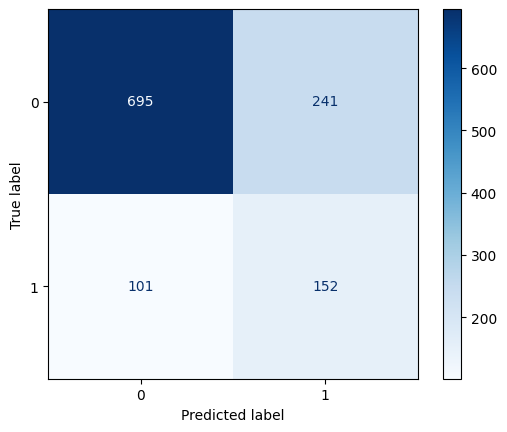

In [143]:
y_pred = grid_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')

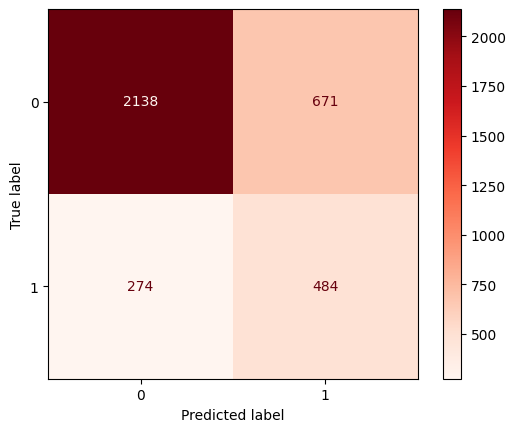

In [144]:
y_pred_train = grid_search.predict(X_train)
cm = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm).plot(cmap='Reds')

In [145]:
# 🔹 Predicciones en TRAIN
y_train_pred = grid_search.predict(X_train)
y_train_prob = grid_search.predict_proba(X_train)[:, 1]

# 🔹 Predicciones en TEST
y_test_pred = grid_search.predict(X_test)
y_test_prob = grid_search.predict_proba(X_test)[:, 1]

# 🔹 Crear tabla comparativa
resultados = {
    'Dataset': ['Train', 'Test'],
    'Precision': [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],
    'F1 Score': [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_train, y_train_prob),
        roc_auc_score(y_test, y_test_prob)
    ]
}

metricas_tree = pd.DataFrame(resultados)
metricas_tree


,Dataset,Precision,Recall,F1 Score,ROC AUC
0,Train,0.419048,0.638522,0.506012,0.769266
1,Test,0.386768,0.600791,0.470588,0.717837


In [146]:
def plot_feature_importances_cancer(model):
    n_features = df.data.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), df.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

In [147]:
plot_feature_importances_cancer(grid_search)

AttributeError: 'DataFrame' object has no attribute 'data'